In [2]:
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
nt = 500
nx = 51 
ny = 51

nu = 0.1
dt = 0.001


In [4]:

dx = 2/(nx - 1)
dy = 2/(ny - 1)

In [5]:
x = np.linspace(0, 2, nx)
y = np.linspace(0, 2, ny)

In [6]:
comb = np.zeros((nx, ny))
comb.shape

(51, 51)

In [7]:
u = np.zeros((ny, nx))
v = np.zeros((ny, nx))

un = np.zeros((ny, nx))
vn = np.zeros((ny, nx))

uf = np.zeros((nt, ny, nx))
vf = np.zeros((nt, ny, nx))

In [8]:
u = np.ones((ny, nx))
v = np.ones((ny, nx))

uf = np.ones((nt, ny, nx))
vf = np.ones((nt, ny, nx))

u[int(0.75/dx):int(1.25/dy+1), int(0.75/dy):int(1.25/dy+1)] = 5
v[int(0.75/dx):int(1.25/dy+1), int(0.75/dy):int(1.25/dy+1)] = 5

uf[0, int(0.75/dx):int(1.25/dy+1), int(0.75/dy):int(1.25/dy+1)] = 5
vf[0 ,int(0.75/dx):int(1.25/dy+1), int(0.75/dy):int(1.25/dy+1)] = 5


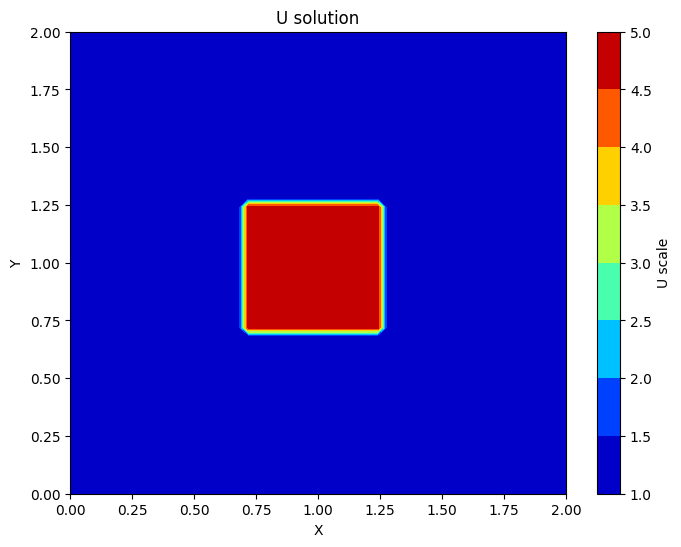

In [9]:
X, Y = np.meshgrid(x, y)

plt.figure(figsize=(8,6))
contour = plt.contourf(X, Y, u[:], cmap='jet')
plt.title("U solution")
plt.xlabel("X")
plt.ylabel("Y")
colorbar = plt.colorbar(contour)
colorbar.set_label("U scale")

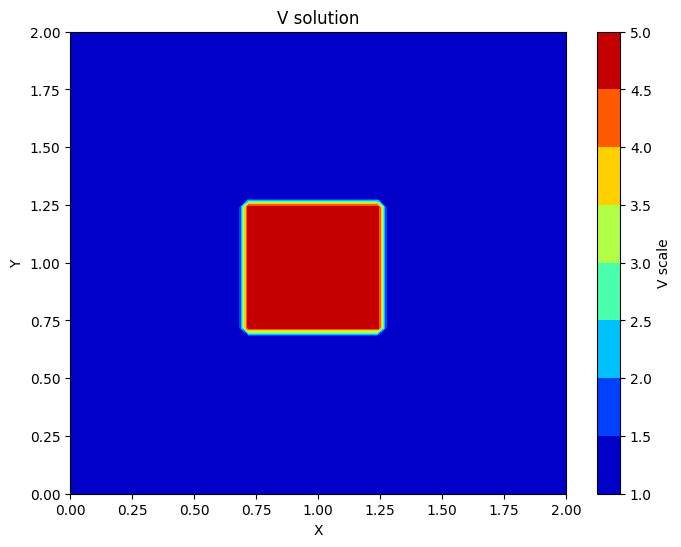

In [10]:
plt.figure(figsize=(8,6))
contour = plt.contourf(X, Y, v[:], cmap='jet')
plt.title("V solution")
plt.xlabel("X")
plt.ylabel("Y")
colorbar = plt.colorbar(contour)
colorbar.set_label("V scale")

In [12]:
for n in range(1, nt):
    un = u.copy()
    vn = v.copy()
    
    for i in range(1, nx - 1):
        for j in range(1, ny - 1):
            u[i, j] = (
                un[i, j]
                - un[i, j] * dt / dx * (un[i, j] - un[i - 1, j])
                - vn[i, j] * dt / dy * (un[i, j] - un[i, j - 1])
                + nu * dt / dx**2 * (un[i + 1, j] - 2 * un[i, j] + un[i - 1, j])
                + nu * dt / dy**2 * (un[i, j + 1] - 2 * un[i, j] + un[i, j - 1])
            )
            
            v[i, j] = (
                vn[i, j]
                - un[i, j] * dt / dx * (vn[i, j] - vn[i - 1, j])
                - vn[i, j] * dt / dy * (vn[i, j] - vn[i, j - 1])
                + nu * dt / dx**2 * (vn[i + 1, j] - 2 * vn[i, j] + vn[i - 1, j])
                + nu * dt / dy**2 * (vn[i, j + 1] - 2 * vn[i, j] + vn[i, j - 1])
            )

            uf[n, i, j] = u[i,j]
            vf[n, i, j] = v[i, j]
    
    u[:,0] = 1
    u[:,-1] = 1
    u[0,: ] = 1
    u[-1,:] = 1
    v[:,0] = 1
    v[:,-1] = 1
    v[0,:] = 1
    v[-1,:] = 1

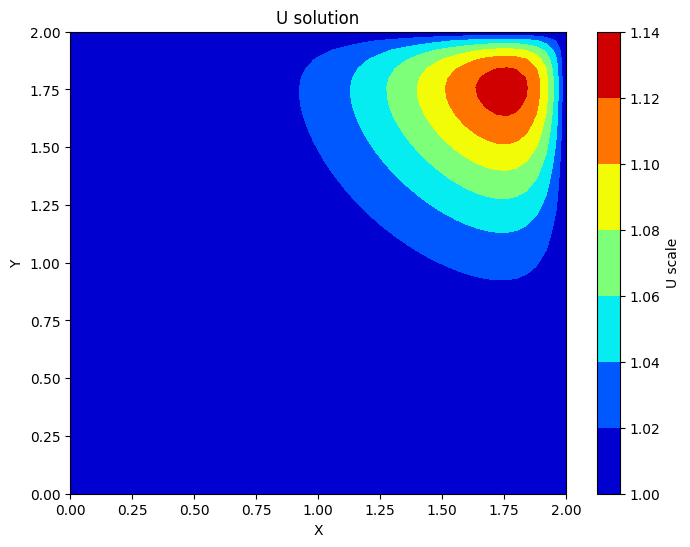

In [14]:
X, Y = np.meshgrid(x, y)

plt.figure(figsize=(8,6))
contour = plt.contourf(X, Y, u[:], cmap='jet')
plt.title("U solution")
plt.xlabel("X")
plt.ylabel("Y")
colorbar = plt.colorbar(contour)
colorbar.set_label("U scale")

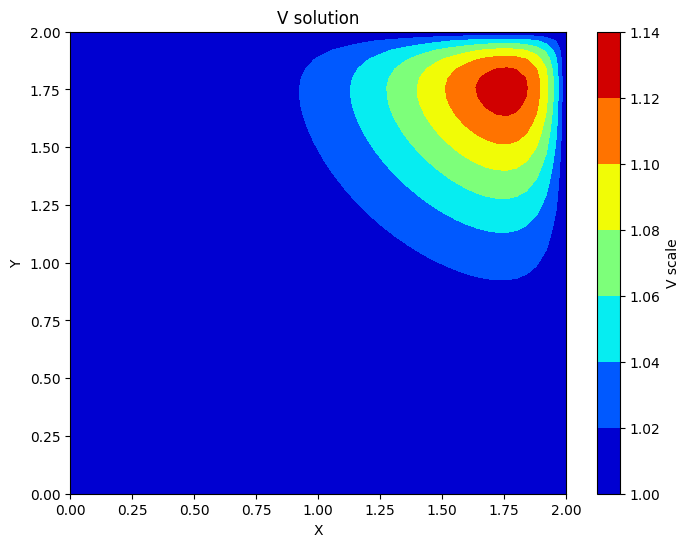

In [15]:
X, Y = np.meshgrid(x, y)

plt.figure(figsize=(8,6))
contour = plt.contourf(X, Y, v[:], cmap='jet')
plt.title("V solution")
plt.xlabel("X")
plt.ylabel("Y")
colorbar = plt.colorbar(contour)
colorbar.set_label("V scale")